# Project: Ham vs. Spam (Text Classification)

The goal of this project is to train and evaluate logistical classifier models to create an email spam filter.

First, we must import the needed libraries and load our dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from cattrs import cols
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [2]:
# Creating the pandas dataframe so we can load it into our notebook
df = pd.read_csv('./data/spam.csv', encoding='latin-1') # The encoding needs to be specified as it is latin-1

## Exploratory Data Analysis

Now that the dataset is loaded into a oandas dataframe, we can inspect it to ensure we understand the data before we start training the models.

In [3]:
# Evaluating the number of columns and rows
print("There are", df.shape[0], "rows and", df.shape[1], "columns in the dataset.")

There are 5572 rows and 5 columns in the dataset.


In [4]:
# Defining a data audit function that will help quickly evaluate key characteristics of the dataset
def data_audit(df: pd.DataFrame, n_unique_preview: int = 8) -> pd.DataFrame:
    summary = []
    for col in df.columns:
        s = df[col]
        summary.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_missing": int(s.isna().sum()),
            "pct_missing": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=True)),
            "example_values": ", ".join(map(str, s.dropna().unique()[:n_unique_preview])),
        })
    out = pd.DataFrame(summary).sort_values(["pct_missing", "n_unique"], ascending=[False, True])
    return out

In [5]:
# Running the data audit on the dataframe
audit = data_audit(df)
audit.head(20)

,column,dtype,n_missing,pct_missing,n_unique,example_values
4,Unnamed: 4,str,5566,0.998923,5,"just Keep-in-touch\"" gdeve.."", GNT:-)"", Neve..."
3,Unnamed: 3,str,5560,0.997846,10,"MK17 92H. 450Ppw 16"", why to miss them, GE, ..."
2,Unnamed: 2,str,5522,0.991027,43,"PO Box 5249, the person is definitely specia..."
0,v1,str,0,0.000000,2,"ham, spam"
1,v2,str,0,0.000000,5169,"Go until jurong point, crazy.. Available only ..."


It looks like we can drop the 3 "unnamed" columns because almost all of them are empty. The important columns are `v1` and `v2`. `v1` is the message label and `v2` is the message text.

In [6]:
df = df[['v1', 'v2']].rename(columns={ 'v1': 'label', 'v2': 'message'}) # Creating a new dataframe with only the relevant columns and renaming the columns
print("The first five rows of the new dataframe are:\n\n", df.head(5))

The first five rows of the new dataframe are:

   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [7]:
duplicate_label_counts = df[df.duplicated(subset='message', keep=False)]['label'].value_counts()

print("Duplicate messages by label:")
print(duplicate_label_counts)
print()
print("Duplicate messages by label (%):")
print(round(duplicate_label_counts / duplicate_label_counts.sum() * 100, 1))

Duplicate messages by label:
label
ham     503
spam    181
Name: count, dtype: int64

Duplicate messages by label (%):
label
ham     73.5
spam    26.5
Name: count, dtype: float64


It's a good idea to see what sort of duplicates the ham messages have.

In [8]:
ham_value_counts = df[df['label'] == 'ham']['message'].value_counts()
print(ham_value_counts)

message
Sorry, I'll call later                                                                                                                                                                 30
I cant pick the phone right now. Pls send a message                                                                                                                                    12
Ok...                                                                                                                                                                                  10
Wen ur lovable bcums angry wid u, dnt take it seriously.. Coz being angry is d most childish n true way of showing deep affection, care n luv!.. kettoda manda... Have nice day da.     4
Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..                                                4
                                                              

The duplicated ham messages appear to be auto-responses or suggested responses. We should do the same for the spam messages.

In [9]:
spam_value_counts = df[df['label'] == 'spam']['message'].value_counts()
print(spam_value_counts)

message
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed å£1000 cash or å£5000 prize!                   4
HMV BONUS SPECIAL 500 pounds of genuine HMV vouchers to be won. Just answer 4 easy questions. Play Now! Send HMV to 86688 More info:www.100percent-real.com             3
Loan for any purpose å£500 - å£75,000. Homeowners + Tenants welcome. Have you been previously refused? We can still help. Call Free 0800 1956669 or text back 'help'    3
FREE for 1st week! No1 Nokia tone 4 ur mob every week just txt NOKIA to 8007 Get txting and tell ur mates www.getzed.co.uk POBox 36504 W45WQ norm150p/tone 16+          3
I don't know u and u don't know me. Send CHAT to 86688 now and let's find each other! Only 150p/Msg rcvd. HG/Suite342/2Lands/Row/W1J6HL LDN. 18 years or over.          3
                                                                                                                                              

The hightest number of duplicates for a spam message is 4, whereas for ham messages it's 30. We need to drop the duplicates before we do our train/test split to avoid under or overfitting.

In [10]:
total_duplicates = df.duplicated(subset='message').sum()
print('There are', total_duplicates, 'total duplicate messages in the dataset.')

There are 403 total duplicate messages in the dataset.


In [11]:
# Dropping duplicates
df = df.drop_duplicates(subset='message')
df['message'].value_counts();

The duplicate messages have now been removed from the dataset.

In [12]:
print(df['label'].value_counts()) # Printing the number of messages by label
print()
print(round(df['label'].value_counts(normalize=True) * 100, 1)) # Printing the percentage of messages by label

label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.4
spam    12.6
Name: proportion, dtype: float64


In [13]:
print(df[df['label'] == 'spam'].head(3))
print()
print(df[df['label'] == 'ham'].head(3))

  label                                            message
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
8  spam  WINNER!! As a valued network customer you have...

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
3   ham  U dun say so early hor... U c already then say...


In [14]:
# Creating a new column 'char_count' to calculate the number of characters in each message
df['char_count'] = df['message'].str.len()

In [15]:
# Calculating the average number of characters in each message type
df.groupby('label')['char_count'].mean()

label
ham      70.459256
spam    137.891271
Name: char_count, dtype: float64

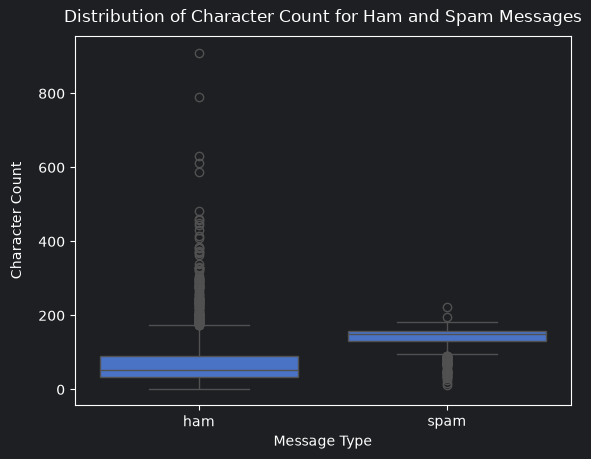

In [16]:
# Creating a boxplot to evaluate distribution of character counts by message label
sns.boxplot(data=df, x='label', y='char_count')
plt.xlabel('Message Type')
plt.ylabel('Character Count', labelpad=10)
plt.title('Distribution of Character Count for Ham and Spam Messages', pad=10)
plt.show()

The boxplot shows the median number of characters for spam messages are higher than ham messages, but the variance of the number of characters for ham messages is much larger than for spam messages.

Now we can train a machine learning model to make predictions!

In [17]:
# Splitting the dataset into training and testing sets
X = df['message']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # Stratifying the data by label to ensure proper sampling

In [18]:
# Making a CountVectorizer object
vectorizer_unigram = CountVectorizer()
X_train_vec_unigram = vectorizer_unigram.fit_transform(X_train)
X_test_vec_unigram = vectorizer_unigram.transform(X_test)

# Making a CountVectorizer object with ngram_range = (1,2)
vectorizer_bigram = CountVectorizer(ngram_range=(1,2))
X_train_vec_bigram = vectorizer_bigram.fit_transform(X_train)
X_test_vec_bigram = vectorizer_bigram.transform(X_test)

In [19]:
print("The number of features identified by the unigram vectorizer is", f"{X_train_vec_unigram.shape[1]:,}")
print("The number of features identified by the bigram vectorizer is", f"{X_train_vec_bigram.shape[1]:,}")

The number of features identified by the unigram vectorizer is 7,295
The number of features identified by the bigram vectorizer is 40,175


The number of features identified by the bigram vectorizer is significantly larger than the unigram vectorizer.

In [20]:
# Training and evaluating a baseline model
baseline_unigram = DummyClassifier(strategy='most_frequent')
baseline_unigram.fit(X_train_vec_unigram, y_train)
y_pred_baseline_unigram = baseline_unigram.predict(X_test_vec_unigram)

# Training and evaluating a baseline model with bigram vectorizer
baseline_bigram = DummyClassifier(strategy='most_frequent')
baseline_bigram.fit(X_train_vec_bigram, y_train)
y_pred_baseline_bigram = baseline_bigram.predict(X_test_vec_bigram)

# Calculating the accuracy scores
baseline_accuracy_unigram = accuracy_score(y_test, y_pred_baseline_unigram)
baseline_accuracy_bigram = accuracy_score(y_test, y_pred_baseline_bigram)

print("Baseline accuracy:", baseline_accuracy_unigram)
print("Baseline accuracy (bigram):", baseline_accuracy_bigram)
print("The accuracy scores are identical:", baseline_accuracy_unigram == baseline_accuracy_bigram)

Baseline accuracy: 0.8739365815931941
Baseline accuracy (bigram): 0.8739365815931941
The accuracy scores are identical: True


Using the DummyClassifier with the unigram and bigram vectorizer showed the accuracy scores are identical. It's interesting to note that the accuracy scores are the same despite the bigram model having thousands more features. Practically, this indicates that in deployment, the unigram vectorizer would have the same accuracy but would be more efficient. We'll investigate further to see if this assumption is true.

In [21]:
# Training and evaluating a unigram logistic regression model
model_unigram = LogisticRegression()
model_unigram.fit(X_train_vec_unigram, y_train)
y_pred_unigram = model_unigram.predict(X_test_vec_unigram)

# Training and evaluating a logistic regression model with bigram vectorizer
model_bigram = LogisticRegression()
model_bigram.fit(X_train_vec_bigram, y_train)
y_pred_bigram = model_bigram.predict(X_test_vec_bigram)

# Calculating the accuracy scores
logreg_accuracy_unigram = accuracy_score(y_test, y_pred_unigram)
logreg_accuracy_bigram = accuracy_score(y_test, y_pred_bigram)
print("Model accuracy (unigram):", logreg_accuracy_unigram)
print("Model accuracy (bigram):", logreg_accuracy_bigram)
percent_accuracy_diff = round(((logreg_accuracy_bigram - logreg_accuracy_unigram) / logreg_accuracy_bigram) * 100, 2)
print("The bigram accuracy score is", abs(percent_accuracy_diff), "%", ("higher" if percent_accuracy_diff > 0 else ( "lower" if percent_accuracy_diff < 0 else "equal")), "than the unigram accuracy score.\n")

# Calculating the precision scores
logreg_precision_unigram = precision_score(y_test, y_pred_unigram, pos_label='spam')
logreg_precision_bigram = precision_score(y_test, y_pred_bigram, pos_label='spam')
print("Model precision (unigram):", logreg_precision_unigram)
print("Model precision (bigram):", logreg_precision_bigram)
percent_precision_diff = round(((logreg_precision_bigram - logreg_precision_unigram) / logreg_precision_bigram) * 100, 2)
print("The bigram precision score is", abs(percent_precision_diff), "%", ("higher" if percent_precision_diff > 0 else ( "lower" if percent_precision_diff < 0 else "equal")), "than the unigram precision score.\n")

# Calculating the recall scores
logreg_recall_unigram = recall_score(y_test, y_pred_unigram, pos_label='spam')
logreg_recall_bigram = recall_score(y_test, y_pred_bigram, pos_label='spam')
print("Model recall (unigram):", logreg_recall_unigram)
print("Model recall (bigram):", logreg_recall_bigram)
percent_recall_diff = round(((logreg_recall_bigram - logreg_recall_unigram) / logreg_recall_bigram) * 100, 2)
print("The bigram recall score is", abs(percent_recall_diff), "%", ("higher" if percent_recall_diff > 0 else ( "lower" if percent_recall_diff < 0 else "equal")), "than the unigram recall score.\n")

# Calculating the F1 scores
logreg_f1_unigram = f1_score(y_test, y_pred_unigram, pos_label='spam')
logreg_f1_bigram = f1_score(y_test, y_pred_bigram, pos_label='spam')
print("Model F1 score (unigram):", logreg_f1_unigram)
print("Model F1 score (bigram):", logreg_f1_bigram)
percent_f1_diff = round(((logreg_f1_bigram - logreg_f1_unigram) / logreg_f1_bigram) * 100, 2)
print("The bigram f1 score is", abs(percent_f1_diff), "%", ("higher" if percent_recall_diff > 0 else ( "lower" if percent_recall_diff < 0 else "equal")), "than the unigram recall score.")

Model accuracy (unigram): 0.9791183294663574
Model accuracy (bigram): 0.9775715390564579
The bigram accuracy score is 0.16 % lower than the unigram accuracy score.

Model precision (unigram): 0.9857142857142858
Model precision (bigram): 1.0
The bigram precision score is 1.43 % higher than the unigram precision score.

Model recall (unigram): 0.8466257668711656
Model recall (bigram): 0.8220858895705522
The bigram recall score is 2.99 % lower than the unigram recall score.

Model F1 score (unigram): 0.9108910891089109
Model F1 score (bigram): 0.9023569023569024
The bigram f1 score is 0.95 % lower than the unigram recall score.


### Unigram Logistic Regression Results

In [22]:
print(model_unigram.classes_)

['ham' 'spam']


In [23]:
accuracy_unigram = accuracy_score(y_test, y_pred_unigram)
precision_unigram = precision_score(y_test, y_pred_unigram, pos_label='spam')
recall_unigram = recall_score(y_test, y_pred_unigram, pos_label='spam')
f1_unigram = f1_score(y_test, y_pred_unigram, pos_label='spam')

print(confusion_matrix(y_test, y_pred_unigram), "\n")

# Calculating the false positive and false negative rates
true_positives_unigram = confusion_matrix(y_test, y_pred_unigram)[1, 1]
false_positives_unigram = confusion_matrix(y_test, y_pred_unigram)[0, 1]
true_negatives_unigram = confusion_matrix(y_test, y_pred_unigram)[0, 0]
false_negatives_unigram = confusion_matrix(y_test, y_pred_unigram)[1, 0]

print("True positives:", true_positives_unigram)
print("False positives:", false_positives_unigram)
print("True negatives:", true_negatives_unigram)
print("False negatives:", false_negatives_unigram, "\n")

print("Accuracy (unigram):", accuracy_unigram)
print("Precision (unigram):", precision_unigram)
print("Recall (unigram):", recall_unigram)
print("F1 (unigram):", f1_unigram, "\n")

print("There were" , false_positives_unigram, "ham messages incorrectly classified as spam (false positives) and",
      false_negatives_unigram, "spam messages incorrectly classified as ham (false negatives).")

[[1128    2]
 [  25  138]] 

True positives: 138
False positives: 2
True negatives: 1128
False negatives: 25 

Accuracy (unigram): 0.9791183294663574
Precision (unigram): 0.9857142857142858
Recall (unigram): 0.8466257668711656
F1 (unigram): 0.9108910891089109 

There were 2 ham messages incorrectly classified as spam (false positives) and 25 spam messages incorrectly classified as ham (false negatives).


The probability threshold for ham/spam is currently 50/50. We can increase the threshold to 80/20 to ensure that as many ham messages are caught as possible.

In [24]:
y_proba_unigram = model_unigram.predict_proba(X_test_vec_unigram)
y_pred_thresh_unigram = np.where(y_proba_unigram[:,1] > 0.8, 'spam', 'ham')

accuracy_thresh_unigram = accuracy_score(y_test, y_pred_thresh_unigram)
precision_thresh_unigram = precision_score(y_test, y_pred_thresh_unigram, pos_label='spam')
recall_thresh_unigram = recall_score(y_test, y_pred_thresh_unigram, pos_label='spam')
f1_thresh_unigram = f1_score(y_test, y_pred_thresh_unigram, pos_label='spam')

print(confusion_matrix(y_test, y_pred_thresh_unigram), "\n")

true_positives_thresh_unigram = confusion_matrix(y_test, y_pred_thresh_unigram)[1, 1]
false_positives_thresh_unigram = confusion_matrix(y_test, y_pred_thresh_unigram)[0, 1]
true_negatives_thresh_unigram = confusion_matrix(y_test, y_pred_thresh_unigram)[0, 0]
false_negatives_thresh_unigram = confusion_matrix(y_test, y_pred_thresh_unigram)[1, 0]

print("True positives (unigram):", true_positives_thresh_unigram)
print("False positives (unigram):", false_positives_thresh_unigram)
print("True negatives (unigram):", true_negatives_thresh_unigram)
print("False negatives (unigram):", false_negatives_thresh_unigram, "\n")

print("Accuracy (unigram):", accuracy_thresh_unigram)
print("Precision (unigram):", precision_thresh_unigram)
print("Recall (unigram):", recall_thresh_unigram)
print("F1 (unigram):", f1_thresh_unigram, "\n")

print("There were" , false_positives_thresh_unigram, "ham messages incorrectly classified as spam (false positives) and",
      false_negatives_thresh_unigram, "spam messages incorrectly classified as ham (false negatives).")

[[1130    0]
 [  37  126]] 

True positives (unigram): 126
False positives (unigram): 0
True negatives (unigram): 1130
False negatives (unigram): 37 

Accuracy (unigram): 0.97138437741686
Precision (unigram): 1.0
Recall (unigram): 0.7730061349693251
F1 (unigram): 0.8719723183391004 

There were 0 ham messages incorrectly classified as spam (false positives) and 37 spam messages incorrectly classified as ham (false negatives).


### Bigram Logistic Regression Results

In [25]:
print(confusion_matrix(y_test, y_pred_bigram), "\n")

accuracy_score_bigram =  accuracy_score(y_test, y_pred_bigram)
precision_score_bigram = precision_score(y_test, y_pred_bigram, pos_label='spam')
recall_score_bigram = recall_score(y_test, y_pred_bigram, pos_label='spam')
f1_score_bigram = f1_score(y_test, y_pred_bigram, pos_label='spam')

true_positives_bigram = confusion_matrix(y_test, y_pred_bigram)[1, 1]
false_positives_bigram = confusion_matrix(y_test, y_pred_bigram)[0, 1]
true_negatives_bigram = confusion_matrix(y_test, y_pred_bigram)[0, 0]
false_negatives_bigram = confusion_matrix(y_test, y_pred_bigram)[1, 0]

print("True positives (bigram):", true_positives_bigram)
print("False positives (bigram):", false_positives_bigram)
print("True negatives (bigram):", true_negatives_bigram)
print("False negatives (bigram):", false_negatives_bigram, "\n")

print("Accuracy (bigram):", accuracy_score_bigram)
print("Precision (bigram):", precision_score_bigram)
print("Recall (bigram):", recall_score_bigram)
print("F1 (bigram):", f1_score_bigram, "\n")

print("There were" , false_positives_bigram, "ham messages incorrectly classified as spam (false positives) and",
      false_negatives_bigram, "spam messages incorrectly classified as ham (false negatives).")

[[1130    0]
 [  29  134]] 

True positives (bigram): 134
False positives (bigram): 0
True negatives (bigram): 1130
False negatives (bigram): 29 

Accuracy (bigram): 0.9775715390564579
Precision (bigram): 1.0
Recall (bigram): 0.8220858895705522
F1 (bigram): 0.9023569023569024 

There were 0 ham messages incorrectly classified as spam (false positives) and 29 spam messages incorrectly classified as ham (false negatives).


The threshold for ham/spam is currently 50/50. We can increase the threshold to 80/20 to ensure that as many ham messages are caught as possible.

In [26]:
y_proba_bigram = model_bigram.predict_proba(X_test_vec_bigram)
y_pred_thresh_bigram = np.where(y_proba_bigram[:,1] > 0.8, 'spam', 'ham')

print(confusion_matrix(y_test, y_pred_thresh_bigram), "\n")
true_positives_thresh_bigram = confusion_matrix(y_test, y_pred_thresh_bigram)[1, 1]
false_positives_thresh_bigram = confusion_matrix(y_test, y_pred_thresh_bigram)[0, 1]
true_negatives_thresh_bigram = confusion_matrix(y_test, y_pred_thresh_bigram)[0, 0]
false_negatives_thresh_bigram = confusion_matrix(y_test, y_pred_thresh_bigram)[1, 0]

print("True positives (bigram):", true_positives_thresh_bigram)
print("False positives (bigram):", false_positives_thresh_bigram)
print("True negatives (bigram):", true_negatives_thresh_bigram)
print("False negatives (bigram):", false_negatives_thresh_bigram, "\n")

print("Accuracy (bigram):", accuracy_score(y_test, y_pred_thresh_bigram))
print("Precision (bigram):", precision_score(y_test, y_pred_thresh_bigram, pos_label='spam'))
print("Recall (bigram):", recall_score(y_test, y_pred_thresh_bigram, pos_label='spam'))
print("F1 (bigram):", f1_score(y_test, y_pred_thresh_bigram, pos_label='spam'), "\n")

print("There were" , false_positives_thresh_bigram, "ham messages incorrectly classified as spam (false positives) and",
      false_negatives_thresh_bigram, "spam messages incorrectly classified as ham (false negatives).")

[[1130    0]
 [  43  120]] 

True positives (bigram): 120
False positives (bigram): 0
True negatives (bigram): 1130
False negatives (bigram): 43 

Accuracy (bigram): 0.9667440061871616
Precision (bigram): 1.0
Recall (bigram): 0.7361963190184049
F1 (bigram): 0.8480565371024735 

There were 0 ham messages incorrectly classified as spam (false positives) and 43 spam messages incorrectly classified as ham (false negatives).


# Conclusion

The goal of this project was to build a machine learning model to automatically identify spam messages in email. We needed to train a model that could accurately identify spam messages as we want to deploy this model to a spam filter. Given the dataset is unbalanced, a random "ham" guess would have a 87% accuracy rate, our model needed to achieve a higher accuracy rate.

For my use case, I wanted to reduce false positives (ham messages) so that I wouldn't miss any important messages in exchange for more spam passing through. The optimal model for my use case is the Bigram model with the standard threshold, as it correctly identified all ham messages with the least amount of false positives.

Given the results of the bigram model, I would be comfortable deploying this model as a basic spam filter. However, the dataset is very small, so the best next step would be to train the model on a larger dataset.

# Next Steps

Planned next steps are to using a decision tree to compare the performance to the logistic regression models.